In [46]:
from stock_data_analyser import StockDataAnalyser
sda= StockDataAnalyser(stock_symbol='AAPL')

In [47]:
sda.fetch_from_db_and_analyze()

In [48]:
df=sda.stock_data

In [49]:
df.head()

,index,Open,High,Low,Close,Volume,EMA,Bollinger_Upper,Bollinger_Lower,Close_Lag1,...,Close_Lag12,Close_Lag13,Close_Lag14,Close_Lag15,Close_Lag16,Close_Lag17,Close_Lag18,Close_Lag19,Trend,Stock_name
0,2025-03-04,237.705,240.0700,234.680,235.93,53798062,224.784136,239.290079,204.582921,235.74,...,214.10,218.27,220.73,223.75,221.53,223.85,217.90,222.13,NaN,AAPL
1,2025-03-03,241.790,244.0272,236.112,238.03,47183985,226.045647,241.519904,203.943096,235.93,...,215.24,214.10,218.27,220.73,223.75,221.53,223.85,217.90,NaN,AAPL
2,2025-02-28,236.950,242.0900,230.200,241.84,56833360,227.549871,244.396215,203.460785,238.03,...,212.69,215.24,214.10,218.27,220.73,223.75,221.53,223.85,NaN,AAPL
3,2025-02-27,239.410,242.4600,237.060,237.30,41153639,228.478455,245.923835,203.278165,241.84,...,214.00,212.69,215.24,214.10,218.27,220.73,223.75,221.53,NaN,AAPL
4,2025-02-26,244.330,244.9800,239.130,240.36,44433564,229.610030,247.930641,203.154359,237.30,...,213.49,214.00,212.69,215.24,214.10,218.27,220.73,223.75,NaN,AAPL


In [91]:
main_data=df[['Close']]
output=df[['High']]

In [93]:
# write code to ignore warnings

import warnings
warnings.filterwarnings('ignore')

for i in range(1, 25):
    main_data[f'Close_Lag{i}'] = main_data['Close'].shift(-i)

main_data.drop(main_data.tail(25).index, inplace=True)
main_data=main_data.drop(['Close'], axis=1)



In [94]:
main_data.corr()

,Close_Lag1,Close_Lag2,Close_Lag3,Close_Lag4,Close_Lag5,Close_Lag6,Close_Lag7,Close_Lag8,Close_Lag9,Close_Lag10,...,Close_Lag15,Close_Lag16,Close_Lag17,Close_Lag18,Close_Lag19,Close_Lag20,Close_Lag21,Close_Lag22,Close_Lag23,Close_Lag24
Close_Lag1,1.000000,0.996011,0.991818,0.987902,0.984216,0.980504,0.976676,0.972673,0.968611,0.964962,...,0.945770,0.941894,0.938096,0.934695,0.931434,0.928029,0.924490,0.920972,0.917465,0.913911
Close_Lag2,0.996011,1.000000,0.996007,0.991797,0.987854,0.984203,0.980497,0.976651,0.972599,0.968534,...,0.949639,0.945682,0.941776,0.937928,0.934496,0.931237,0.927861,0.924295,0.920726,0.917260
Close_Lag3,0.991818,0.996007,1.000000,0.996009,0.991769,0.987830,0.984177,0.980457,0.976574,0.972516,...,0.953203,0.949602,0.945620,0.941637,0.937764,0.934328,0.931118,0.927671,0.924053,0.920504
Close_Lag4,0.987902,0.991797,0.996009,1.000000,0.996000,0.991798,0.987857,0.984184,0.980437,0.976546,...,0.956987,0.953147,0.949524,0.945494,0.941486,0.937611,0.934201,0.930959,0.927474,0.923883
Close_Lag5,0.984216,0.987854,0.991769,0.996000,1.000000,0.996014,0.991800,0.987840,0.984155,0.980397,...,0.960508,0.956964,0.953107,0.949415,0.945368,0.941352,0.937518,0.934038,0.930760,0.927282
Close_Lag6,0.980504,0.984203,0.987830,0.991798,0.996014,1.000000,0.996000,0.991773,0.987793,0.984101,...,0.964501,0.960574,0.957010,0.953040,0.949334,0.945273,0.941329,0.937363,0.933832,0.930547
Close_Lag7,0.976676,0.980497,0.984177,0.987857,0.991800,0.996000,1.000000,0.995988,0.991734,0.987748,...,0.968169,0.964578,0.960627,0.956952,0.952965,0.949246,0.945257,0.941185,0.937163,0.933628
Close_Lag8,0.972673,0.976651,0.980457,0.984184,0.987840,0.991773,0.995988,1.000000,0.995963,0.991701,...,0.972201,0.968232,0.964620,0.960566,0.956874,0.952875,0.949222,0.945119,0.940993,0.936970
Close_Lag9,0.968611,0.972599,0.976574,0.980437,0.984155,0.987793,0.991734,0.995963,1.000000,0.995949,...,0.976248,0.972286,0.968302,0.964584,0.960520,0.956812,0.952881,0.949098,0.944953,0.940808
Close_Lag10,0.964962,0.968534,0.972516,0.976546,0.980397,0.984101,0.987748,0.991701,0.995949,1.000000,...,0.980134,0.976332,0.972354,0.968269,0.964540,0.960461,0.956817,0.952766,0.948943,0.944783


In [95]:

from sklearn.decomposition import PCA
pca=PCA(n_components=4)
temp=pca.fit_transform(main_data)


In [96]:
for i in range(0, temp.shape[1]):
    main_data[f'pca{i}'] = temp[:, i]


In [97]:
main_data.head()

,Close_Lag1,Close_Lag2,Close_Lag3,Close_Lag4,Close_Lag5,Close_Lag6,Close_Lag7,Close_Lag8,Close_Lag9,Close_Lag10,...,Close_Lag19,Close_Lag20,Close_Lag21,Close_Lag22,Close_Lag23,Close_Lag24,pca0,pca1,pca2,pca3
0,238.03,241.84,237.30,240.36,247.04,247.10,245.55,245.83,244.87,244.47,...,232.80,228.01,236.00,237.59,239.36,238.26,314.701945,-11.945388,2.813383,-21.058760
1,241.84,237.30,240.36,247.04,247.10,245.55,245.83,244.87,244.47,244.60,...,228.01,236.00,237.59,239.36,238.26,229.86,313.054147,-14.252480,7.018985,-16.869068
2,237.30,240.36,247.04,247.10,245.55,245.83,244.87,244.47,244.60,241.53,...,236.00,237.59,239.36,238.26,229.86,222.78,309.213873,-17.123614,7.719946,-9.221855
3,240.36,247.04,247.10,245.55,245.83,244.87,244.47,244.60,241.53,236.87,...,237.59,239.36,238.26,229.86,222.78,223.66,306.457792,-20.616803,9.664103,0.919346
4,247.04,247.10,245.55,245.83,244.87,244.47,244.60,241.53,236.87,232.62,...,239.36,238.26,229.86,222.78,223.66,223.83,303.095636,-22.721305,10.269098,9.918214


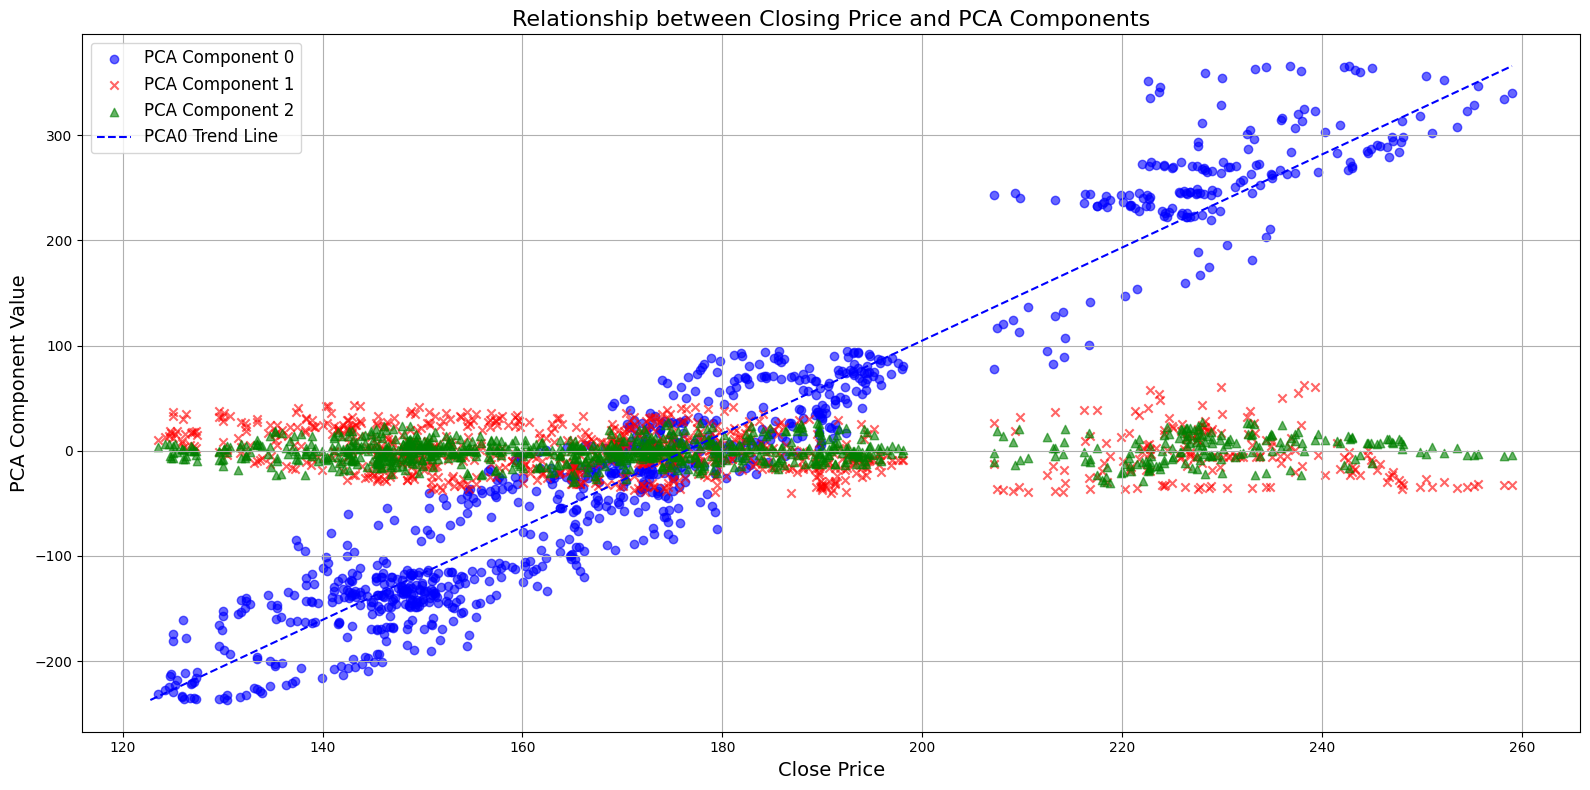

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

# Scatter plots for PCA components
plt.scatter(df['Close'].loc[main_data.index], main_data['pca0'], c='blue', alpha=0.6, label='PCA Component 0', marker='o')
plt.scatter(df['Close'].loc[main_data.index], main_data['pca1'], c='red', alpha=0.6, label='PCA Component 1', marker='x')
plt.scatter(df['Close'].loc[main_data.index], main_data['pca2'], c='green', alpha=0.6, label='PCA Component 2', marker='^')

# Optional: Draw simple line between min and max for pca0 (trend approximation)
x_vals = [df['Close'].min(), df['Close'].max()]
y_vals = [main_data['pca0'].min(), main_data['pca0'].max()]
plt.plot(x_vals, y_vals, color='blue', linestyle='--', label='PCA0 Trend Line')

# Labels and grid
plt.title('Relationship between Closing Price and PCA Components', fontsize=16)
plt.xlabel('Close Price', fontsize=14)
plt.ylabel('PCA Component Value', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


In [99]:
import tensorflow as tf
from tensorflow import keras
from tensorflow import keras
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [100]:
X=main_data[['pca0']]
y=output.loc[main_data.index]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [113]:
# # Define the neural network model
model = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(X.shape[1],)),  
    # keras.layers.LSTM(256, return_sequences=True, input_shape=(X.shape[1],)),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(y.shape[1])  # Output layer for regression (no activation)
])
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense

# model = Sequential()
# model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
# model.add(LSTM(50, return_sequences=True))
# model.add(LSTM(50))
# model.add(Dense(1))

model.compile(loss='mean_squared_error', metrics=['mae'], optimizer='adam')

# from tensorflow.keras.optimizers import Adam
# model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])


from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Increase epochs
EPOCHS = 100

# Train the model with callbacks
model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[ checkpoint, early_stop]
)



Epoch 1/100
22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 162169.9688 - mae: 325.8661
Epoch 1: val_loss improved from inf to 18665.93945, saving model to best_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 159939.8750 - mae: 322.5926 - val_loss: 18665.9395 - val_mae: 123.9841
Epoch 2/100
20/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 100771.3672 - mae: 257.7950 
Epoch 2: val_loss did not improve from 18665.93945
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 99799.3672 - mae: 256.0853 - val_loss: 33825.3125 - val_mae: 151.1573
Epoch 3/100
14/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 92483.9375 - mae: 245.1518 
Epoch 3: val_loss did not improve from 18665.93945
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 92285.5156 - mae: 245.4630 - val_loss: 36922.4922 - val_mae: 155.5997
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92703.6953 - mae: 246.7422
Epoch 4: val_loss did not improve from 18665.93945
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 92699.7031 - m

In [116]:
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)
y_train = y_train
y_test = y_test

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [117]:
y_train.shape, y_train_pred.shape, y_test.shape, y_test_pred.shape

((764, 3), (764, 1), (191, 1), (191, 1))

In [118]:
y_train.reset_index(inplace=True)

ValueError: cannot insert level_0, already exists

In [119]:
y_train_pred[:,0]

array([ 45.36974   , 369.42072   ,  59.372265  , 392.8967    ,
       123.17677   ,  97.57983   ,  85.56382   , 372.76962   ,
        38.839947  , 482.13696   , 365.1399    ,  79.956154  ,
       466.81427   ,  52.679714  ,  58.867733  , 335.9057    ,
       286.6064    , 239.34999   ,  36.555973  , 363.43103   ,
       244.31331   , 165.36003   , 261.51355   ,  24.320711  ,
       235.02153   , 427.07513   , 247.58534   ,  15.549624  ,
       274.48935   , 129.39815   ,  55.088432  ,  93.08816   ,
       368.7167    ,  38.753853  ,  88.35825   ,   3.1722443 ,
       363.43536   , 330.74445   , 222.61107   , 338.99536   ,
        16.943022  , 143.6858    , 500.64966   ,  39.826477  ,
        12.5363    , 438.44696   , 400.0708    , 396.24402   ,
       321.2548    , 216.07306   , 268.86932   , 435.31393   ,
       100.55424   , 157.08658   , 298.00403   , 218.9605    ,
        30.30752   , 325.06885   ,  65.752075  , 252.31596   ,
        21.64535   , 209.04994   , 175.93001   , 114.99

In [83]:
type(y_train["High"])

pandas.core.series.Series

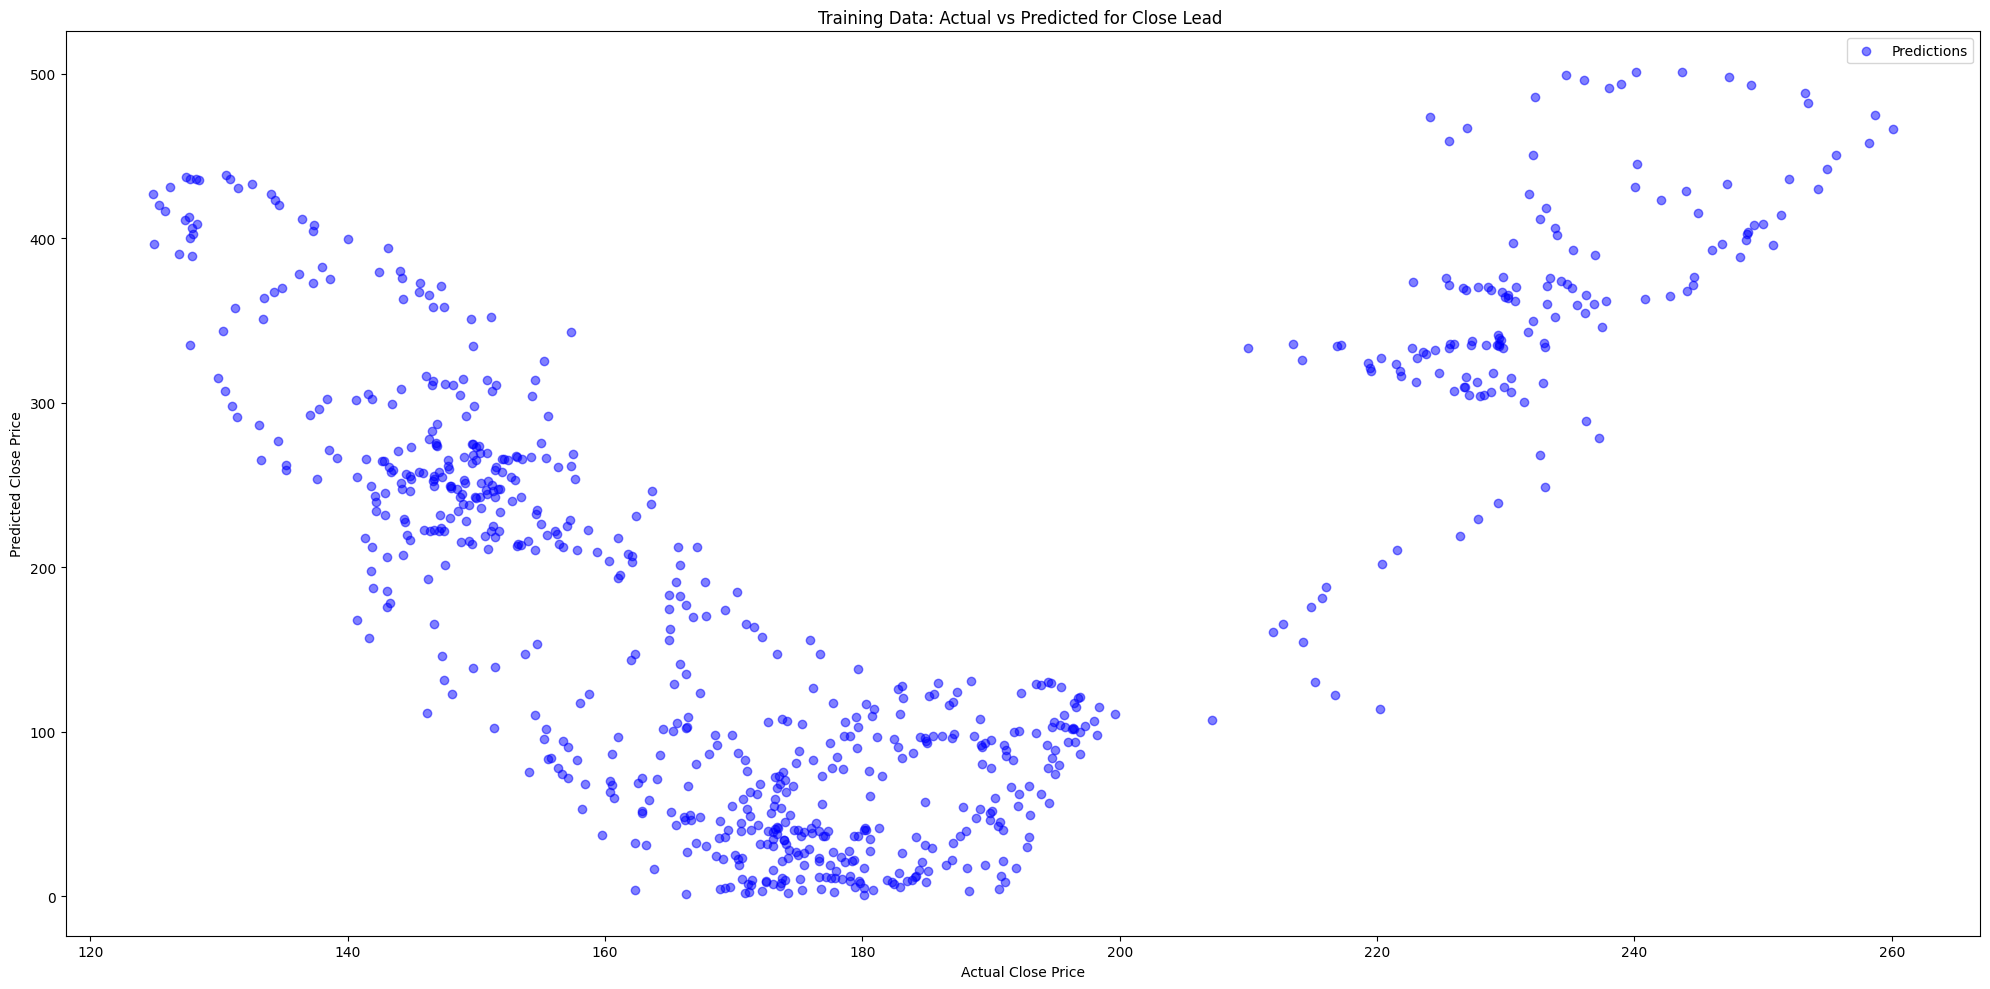

In [120]:
plt.figure(figsize=(20,10))
# for i in range(1,5):
# plt.subplot(2,2,i)
# scalerY.inverse_transform(y_train)
# plt.scatter(scalerY.inverse_transform(y_train), y_train_pred, alpha=0.5, color='blue', label="Predictions")
# plt.plot(scalerY.inverse_transform(y_train), scalerY.inverse_transform(y_train), color='red', linestyle='dashed', label="Ideal Fit")
plt.scatter(y_train['High'].reset_index(drop=True), y_train_pred[:,0], alpha=0.5, color='blue', label="Predictions")
# plt.scatter(y_train['Low'].reset_index(drop=True), y_train_pred[:,1], alpha=0.5, color='red', label="Predictions")
# plt.plot(y_train[:,0], y_train[:,0], color='red', linestyle='dashed', label="Ideal Fit")
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title(f"Training Data: Actual vs Predicted for Close Lead ")
plt.legend()

plt.tight_layout()
plt.show()

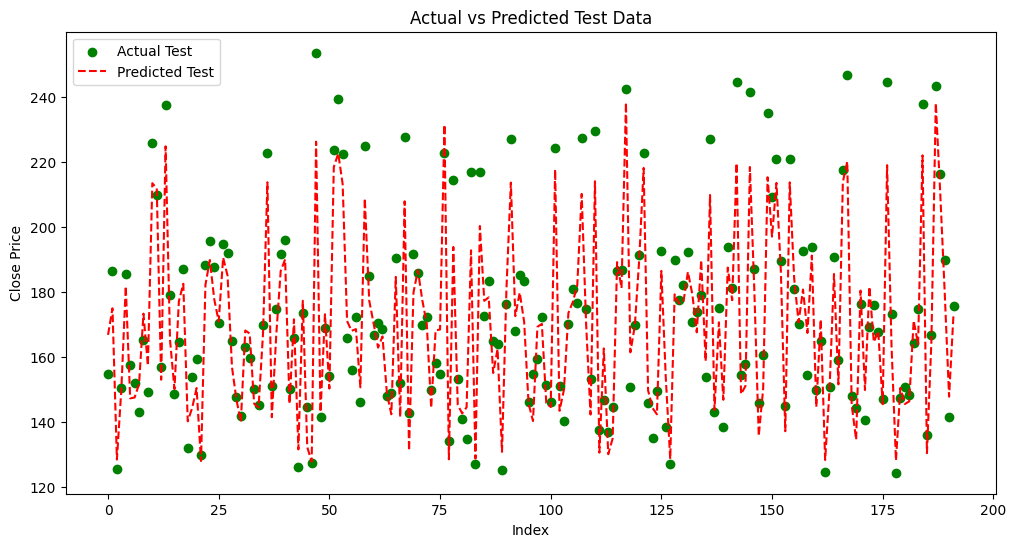

In [18]:
# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.scatter(range(0,  len(y_test)), y_test, label="Actual Test", color='green', linewidth=1)
plt.plot(range(0,  len(y_test)), y_test_pred, label="Predicted Test", color='red', linestyle='dashed')
plt.xlabel("Index")
plt.ylabel("Close Price")
plt.title("Actual vs Predicted Test Data")
plt.legend()
plt.show()